In [4]:
import pandas as pd

raw_path = "infosec_paysim_dataset/PS_20220506045727_390923108_rawLog.csv"

df = pd.read_csv(raw_path)
df.head(), df.columns

(   step    action    amount      nameOrig  oldBalanceOrig  newBalanceOrig  \
 0     0  TRANSFER     62.29   C3005907558           62.29            0.00   
 1     0  CASH_OUT     62.29  CC4841801847           62.29            0.00   
 2     0  TRANSFER     17.33   C2256540102           17.33            0.00   
 3     0  CASH_OUT     17.33  CC1945132177           17.33            0.00   
 4     1   CASH_IN  91237.30   C3571481049           19.39        91256.69   
 
        nameDest  oldBalanceDest  newBalanceDest  isFraud  isFlaggedFraud  \
 0  CC4841801847             0.0           62.29        1               0   
 1   M4982703438             0.0            0.00        1               0   
 2  CC1945132177             0.0           17.33        1               0   
 3   M7293368967             0.0            0.00        1               0   
 4   M8003070016             0.0            0.00        0               0   
 
    isUnauthorizedOverdraft  
 0                        0  
 1    

In [5]:
# 1) Keep only rows where key columns exist
df_clean = df.dropna(subset=["amount", "action", "isFraud"]).copy()

# 2) Make sure amount is numeric and positive
df_clean["amount"] = df_clean["amount"].astype(float)
df_clean = df_clean[df_clean["amount"] > 0]

# 3) Turn the simulation step into an "hour of day" (0–23)
df_clean["hour_of_day"] = (df_clean["step"] % 24).astype(int)

# 4) Simple flags for type of transaction
df_clean["is_cash_out"] = (df_clean["action"] == "CASH_OUT").astype(int)
df_clean["is_transfer"] = (df_clean["action"] == "TRANSFER").astype(int)

# 5) Scale amount so numbers are not too huge
df_clean["amount_scaled"] = df_clean["amount"] / 100000.0

# 6) Define features (X) and label (y)
feature_cols = ["amount_scaled", "hour_of_day", "is_cash_out", "is_transfer"]
X = df_clean[feature_cols]
y = df_clean["isFraud"].astype(int)

X.head(), y.value_counts()

(   amount_scaled  hour_of_day  is_cash_out  is_transfer
 0       0.000623            0            0            1
 1       0.000623            0            1            0
 2       0.000173            0            0            1
 3       0.000173            0            1            0
 4       0.912373            1            0            0,
 isFraud
 0    11560386
 1        4913
 Name: count, dtype: int64)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Take a random sample to make training fast (200,000 rows)
df_sample = df_clean.sample(n=200_000, random_state=42)

X_sample = df_sample[feature_cols]
y_sample = df_sample["isFraud"].astype(int)

y_sample.value_counts()

isFraud
0    199926
1        74
Name: count, dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample,  # keep fraud/non-fraud ratio similar
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[39985     0]
 [   13     2]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     39985
           1      1.000     0.133     0.235        15

    accuracy                          1.000     40000
   macro avg      1.000     0.567     0.618     40000
weighted avg      1.000     1.000     1.000     40000



In [8]:
print("Feature order:", feature_cols)
print("Coefficients:", model.coef_[0])
print("Intercept:", model.intercept_[0])

Feature order: ['amount_scaled', 'hour_of_day', 'is_cash_out', 'is_transfer']
Coefficients: [ 0.25542063 -0.10583575  1.93434754 -2.08010781]
Intercept: -8.603127593517005


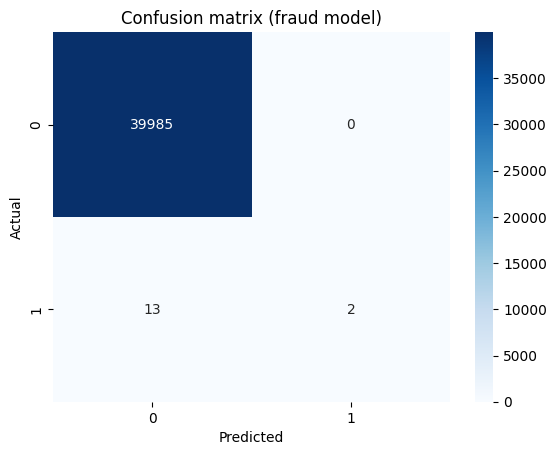

In [10]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix (fraud model)")
plt.show()

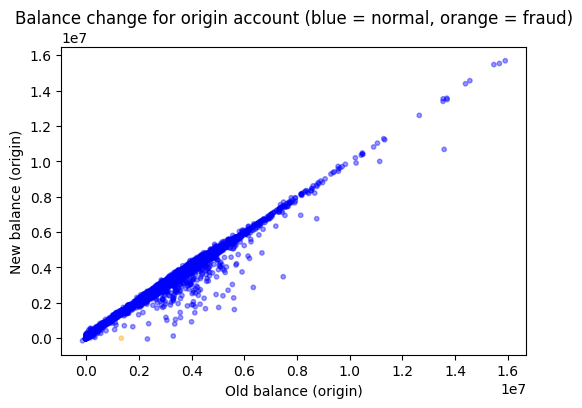

In [12]:
# Take another small sample with balance info
sample_balance = df_clean.sample(n=5000, random_state=3)

plt.figure(figsize=(6, 4))
colors = sample_balance["isFraud"].map({0: "blue", 1: "orange"})

plt.scatter(
    sample_balance["oldBalanceOrig"],
    sample_balance["newBalanceOrig"],
    c=colors,
    alpha=0.4,
    s=10,
)

plt.xlabel("Old balance (origin)")
plt.ylabel("New balance (origin)")
plt.title("Balance change for origin account (blue = normal, orange = fraud)")
plt.show()

In [13]:
fraudsters_path = "infosec_paysim_dataset/PS_20220506045727_390923108_fraudsters.csv"
fraudsters = pd.read_csv(fraudsters_path)
fraudsters.head(), fraudsters.columns

(          name  nbVictims       profit
 0  C1427304573          4  10412865.98
 1  C8528261355          0         0.00
 2  C8007956942          0         0.00
 3  C3293395133          1   2355672.25
 4  C4106570102          1   1980734.48,
 Index(['name', 'nbVictims', 'profit'], dtype='str'))

In [14]:
# Set of known fraudster account names from the fraudsters CSV
fraud_names = set(fraudsters["name"])

# New feature: 1 if origin account in the fraudsters list, else 0
df_clean["isKnownFraudOrig"] = df_clean["nameOrig"].isin(fraud_names).astype(int)

# Update features to include the new column
feature_cols = ["amount_scaled", "hour_of_day", "is_cash_out", "is_transfer", "isKnownFraudOrig"]
X = df_clean[feature_cols]
y = df_clean["isFraud"].astype(int)

X.head(), y.value_counts(), df_clean["isKnownFraudOrig"].value_counts()

(   amount_scaled  hour_of_day  is_cash_out  is_transfer  isKnownFraudOrig
 0       0.000623            0            0            1                 0
 1       0.000623            0            1            0                 0
 2       0.000173            0            0            1                 0
 3       0.000173            0            1            0                 0
 4       0.912373            1            0            0                 0,
 isFraud
 0    11560386
 1        4913
 Name: count, dtype: int64,
 isKnownFraudOrig
 0    11565299
 Name: count, dtype: int64)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Sample for speed
df_sample = df_clean.sample(n=200_000, random_state=42)
X_sample = df_sample[feature_cols]
y_sample = df_sample["isFraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample,
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[39985     0]
 [   13     2]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     39985
           1      1.000     0.133     0.235        15

    accuracy                          1.000     40000
   macro avg      1.000     0.567     0.618     40000
weighted avg      1.000     1.000     1.000     40000



In [16]:
print("Feature order:", feature_cols)
print("Coefficients:", model.coef_[0])
print("Intercept:", model.intercept_[0])

Feature order: ['amount_scaled', 'hour_of_day', 'is_cash_out', 'is_transfer', 'isKnownFraudOrig']
Coefficients: [ 0.25542063 -0.10583575  1.93434754 -2.08010781  0.        ]
Intercept: -8.603127593517005
